# 02 — Cancellation Prediction Model

**Objective:** Predict booking cancellations to enable strategic overbooking and revenue protection.  
**Models:** Logistic Regression (baseline) → Random Forest → XGBoost  
**Key Metric:** ROC-AUC, Precision-Recall with business cost analysis

---

## 1. Setup & Data Preparation

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)

from src.config import COLORS, FIGURES_PATH, DATA_PATH
from src.data_cleaning import load_raw_data, clean_data
from src.feature_engineering import add_features
from src.viz_style import set_theme, GOLD_CMAP

set_theme()
print('Setup complete.')

Setup complete.


In [2]:
# Load and prepare data
raw = load_raw_data(DATA_PATH)
df = clean_data(raw)
df = add_features(df)
print(f'Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')

Dataset: 119,388 rows, 55 columns


## 2. Feature Selection & Encoding

In [3]:
# Select features for modeling (avoid data leakage)
feature_cols = [
    'hotel', 'lead_time', 'arrival_date_month_num', 'arrival_date_week_number',
    'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies',
    'meal', 'country', 'market_segment', 'distribution_channel',
    'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled',
    'reserved_room_type', 'deposit_type', 'agent', 'customer_type',
    'adr', 'required_car_parking_spaces', 'total_of_special_requests',
    'total_nights', 'total_guests', 'is_high_season', 'is_family',
    'has_special_requests',
    # New interaction & behavioral features
    'lead_time_squared', 'stays_ratio', 'is_long_stay',
    'has_agent', 'booking_changes_flag', 'waiting_list_flag',
    'net_previous_bookings', 'cancel_history_ratio',
]

target = 'is_canceled'

model_df = df[feature_cols + [target]].copy()

# Fill remaining NaN
model_df['agent'] = model_df['agent'].fillna(0)

# Label encode categorical columns
cat_cols = model_df.select_dtypes(include='object').columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    le_dict[col] = le

print(f'Features: {len(feature_cols)}')
print(f'Categorical encoded: {cat_cols}')
print(f'Target distribution:\n{model_df[target].value_counts(normalize=True)}')

Features: 36
Categorical encoded: ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']
Target distribution:
is_canceled
0    0.629586
1    0.370414
Name: proportion, dtype: float64


In [4]:
# Train/test split
X = model_df[feature_cols]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

Train: 95,510  |  Test: 23,878


## 3. Model Training & Comparison

In [5]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42,
                             use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    y_pred = (y_pred_proba >= 0.5).astype(int)
    auc = roc_auc_score(y_test, y_pred_proba)
    ap = average_precision_score(y_test, y_pred_proba)
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_pred_proba,
        'auc': auc, 'ap': ap
    }
    print(f'  ROC-AUC: {auc:.4f}  |  Avg Precision: {ap:.4f}')

print('\nDone.')

Training Logistic Regression...


  ROC-AUC: 0.8600  |  Avg Precision: 0.8233
Training Random Forest...


  ROC-AUC: 0.9410  |  Avg Precision: 0.9161
Training Gradient Boosting...


  ROC-AUC: 0.9408  |  Avg Precision: 0.9116
Training XGBoost...


  ROC-AUC: 0.9452  |  Avg Precision: 0.9201
Training LightGBM...


  ROC-AUC: 0.9439  |  Avg Precision: 0.9182

Done.


## 4. Model Evaluation

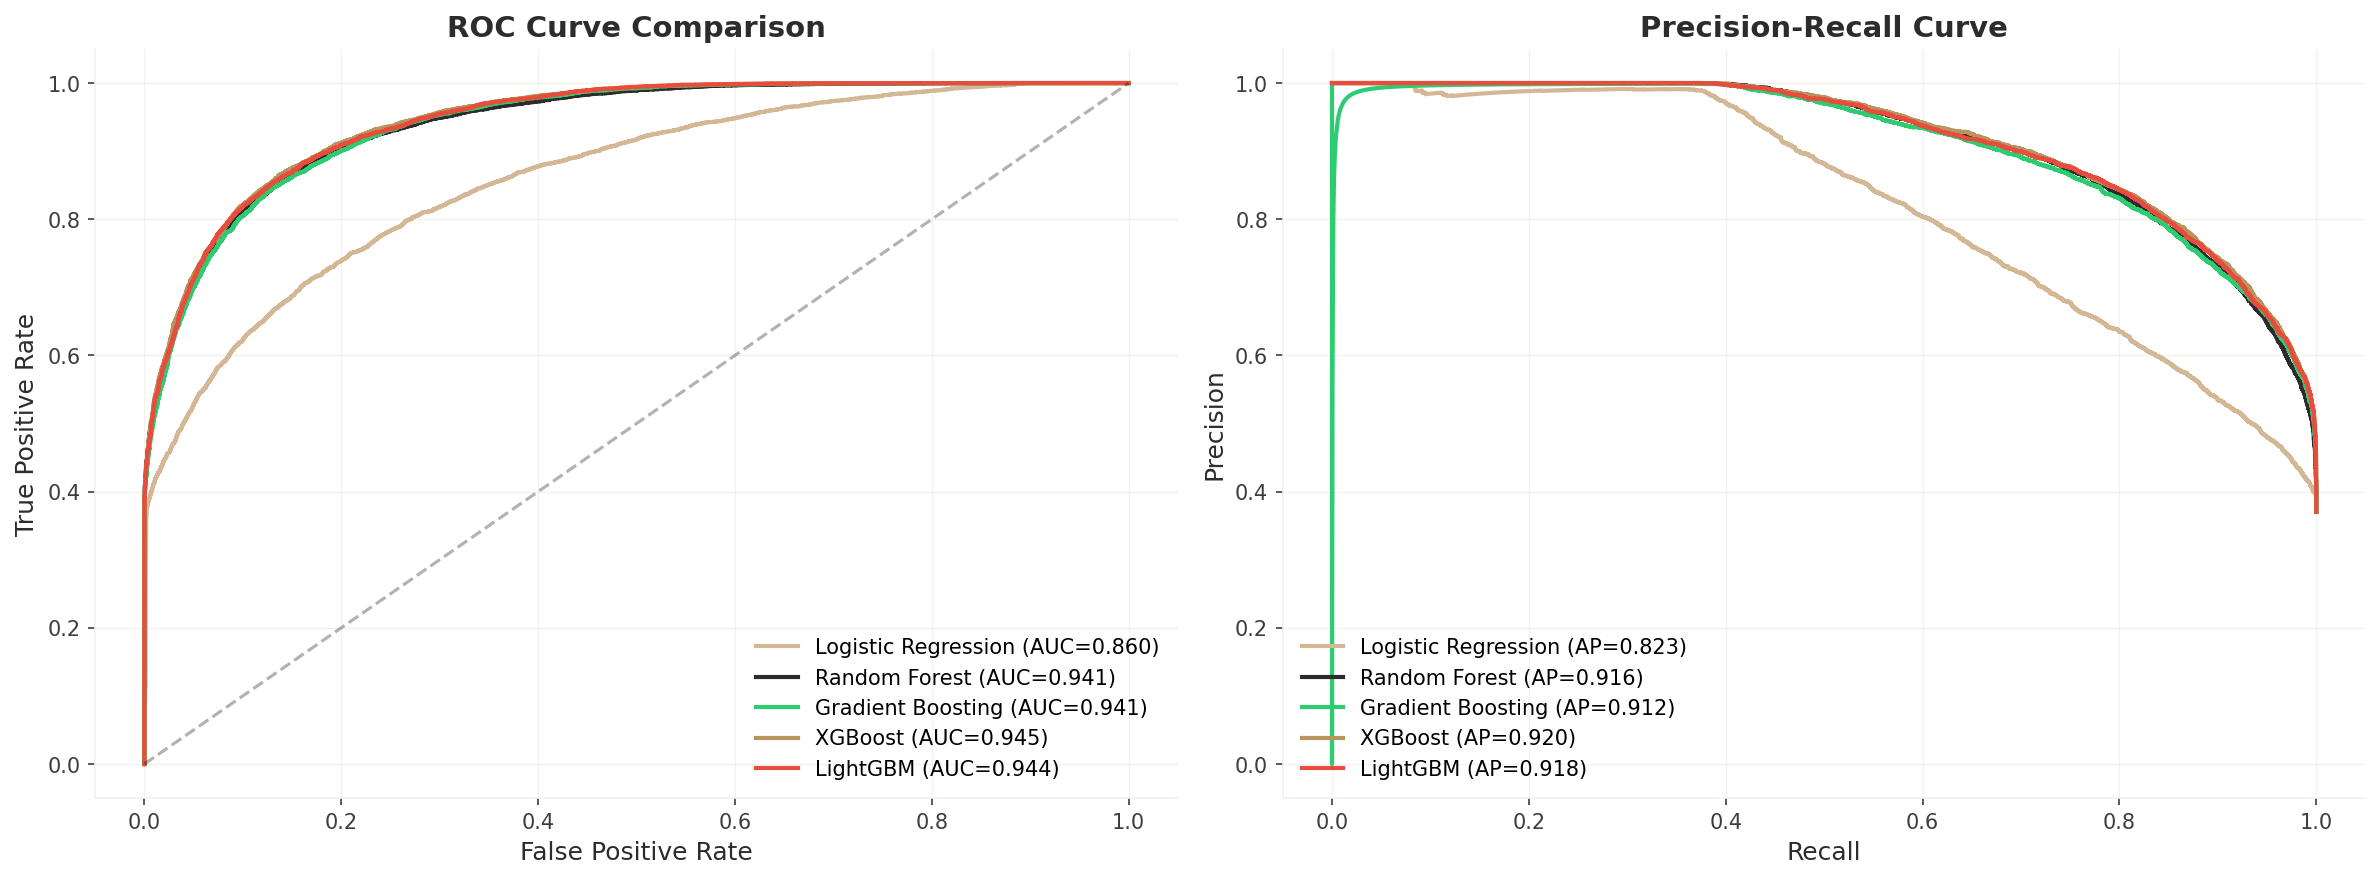

In [6]:
# 4.1 — ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
ax = axes[0]
colors_models = [COLORS['accent'], COLORS['dark'], '#2ecc71', COLORS['primary'], '#e74c3c']
for (name, res), c in zip(results.items(), colors_models):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=c, linewidth=2, label=f"{name} (AUC={res['auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

# Precision-Recall Curve
ax = axes[1]
for (name, res), c in zip(results.items(), colors_models):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ax.plot(rec, prec, color=c, linewidth=2, label=f"{name} (AP={res['ap']:.3f})")
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower left')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}08_model_roc_pr.png')
plt.show()

Best Model: XGBoost (AUC: 0.9452)

              precision    recall  f1-score   support

Not Canceled       0.88      0.92      0.90     15033
    Canceled       0.86      0.78      0.82      8845

    accuracy                           0.87     23878
   macro avg       0.87      0.85      0.86     23878
weighted avg       0.87      0.87      0.87     23878



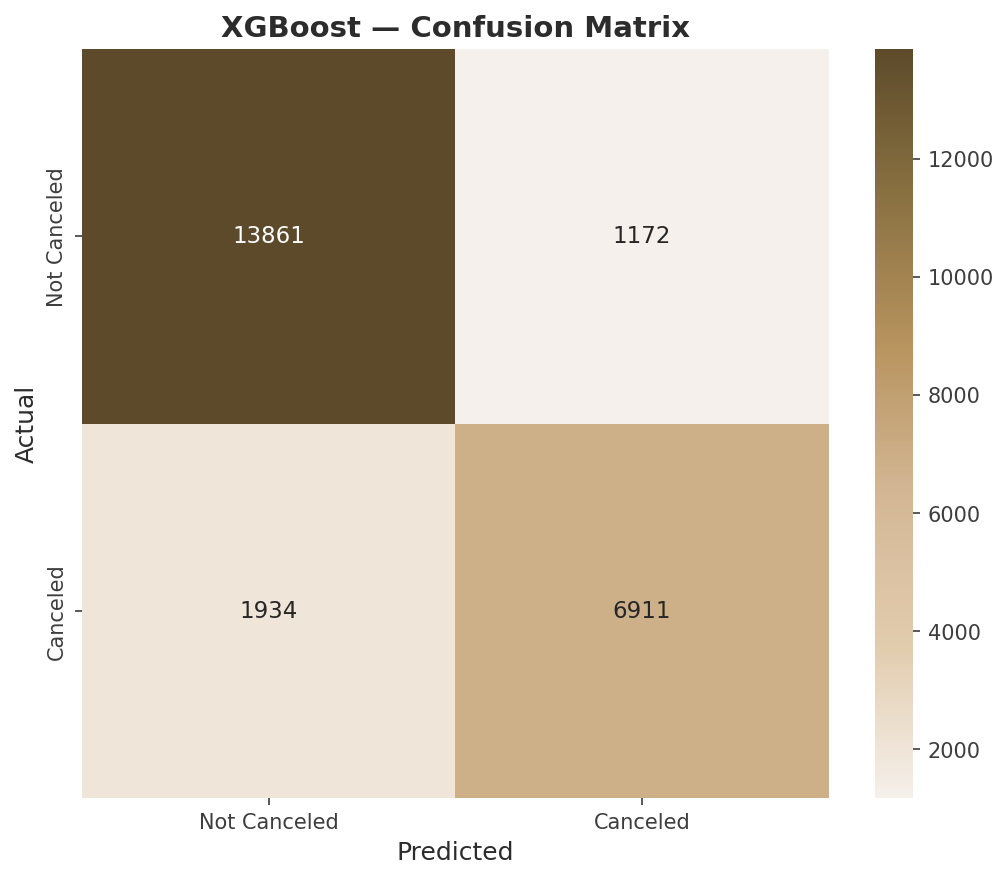

In [7]:
# 4.2 — Confusion Matrix for best model (XGBoost)
best_name = max(results, key=lambda k: results[k]['auc'])
best = results[best_name]
print(f'Best Model: {best_name} (AUC: {best["auc"]:.4f})')
print()
print(classification_report(y_test, best['y_pred'], target_names=['Not Canceled', 'Canceled']))

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap=GOLD_CMAP, ax=ax,
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title(f'{best_name} — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}09_confusion_matrix.png')
plt.show()

## 5. Feature Importance

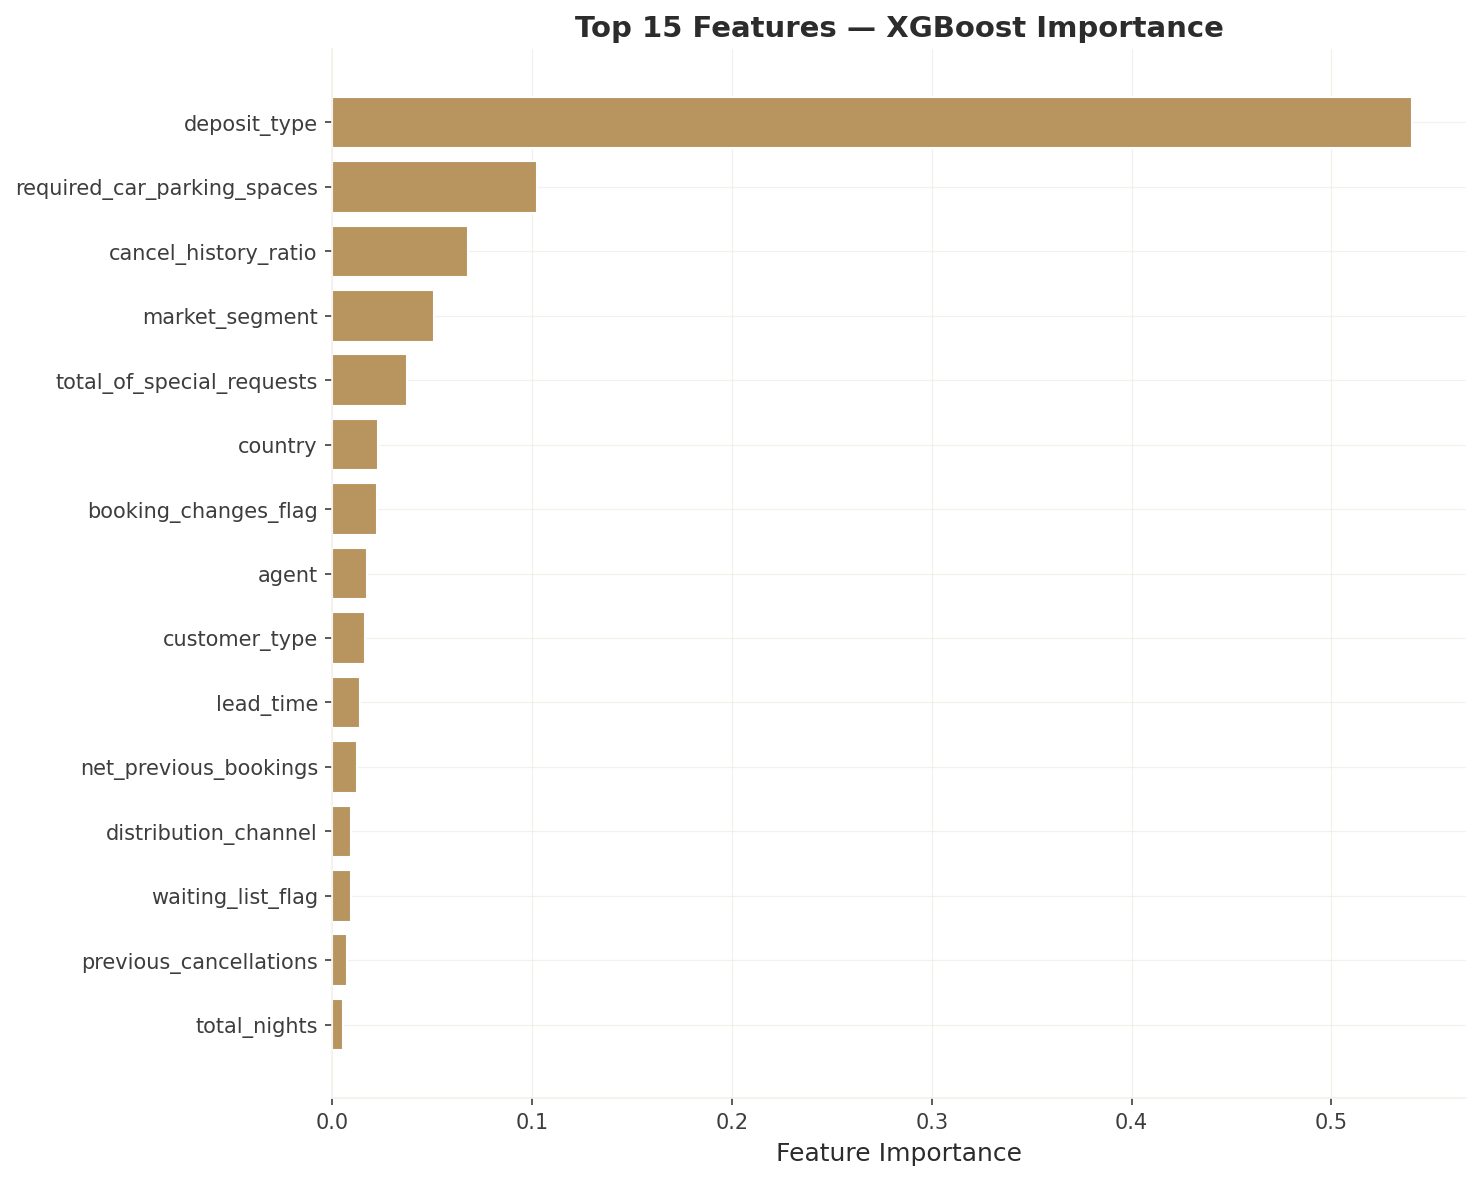

In [8]:
# Feature importance from XGBoost
xgb_model = results['XGBoost']['model']
importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
top_15 = importance.tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_15.index, top_15.values, color=COLORS['primary'], edgecolor='white')
ax.set_title('Top 15 Features — XGBoost Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}10_feature_importance.png')
plt.show()

## 5b. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) provides a more nuanced view of feature importance by showing each feature's actual contribution to individual predictions.

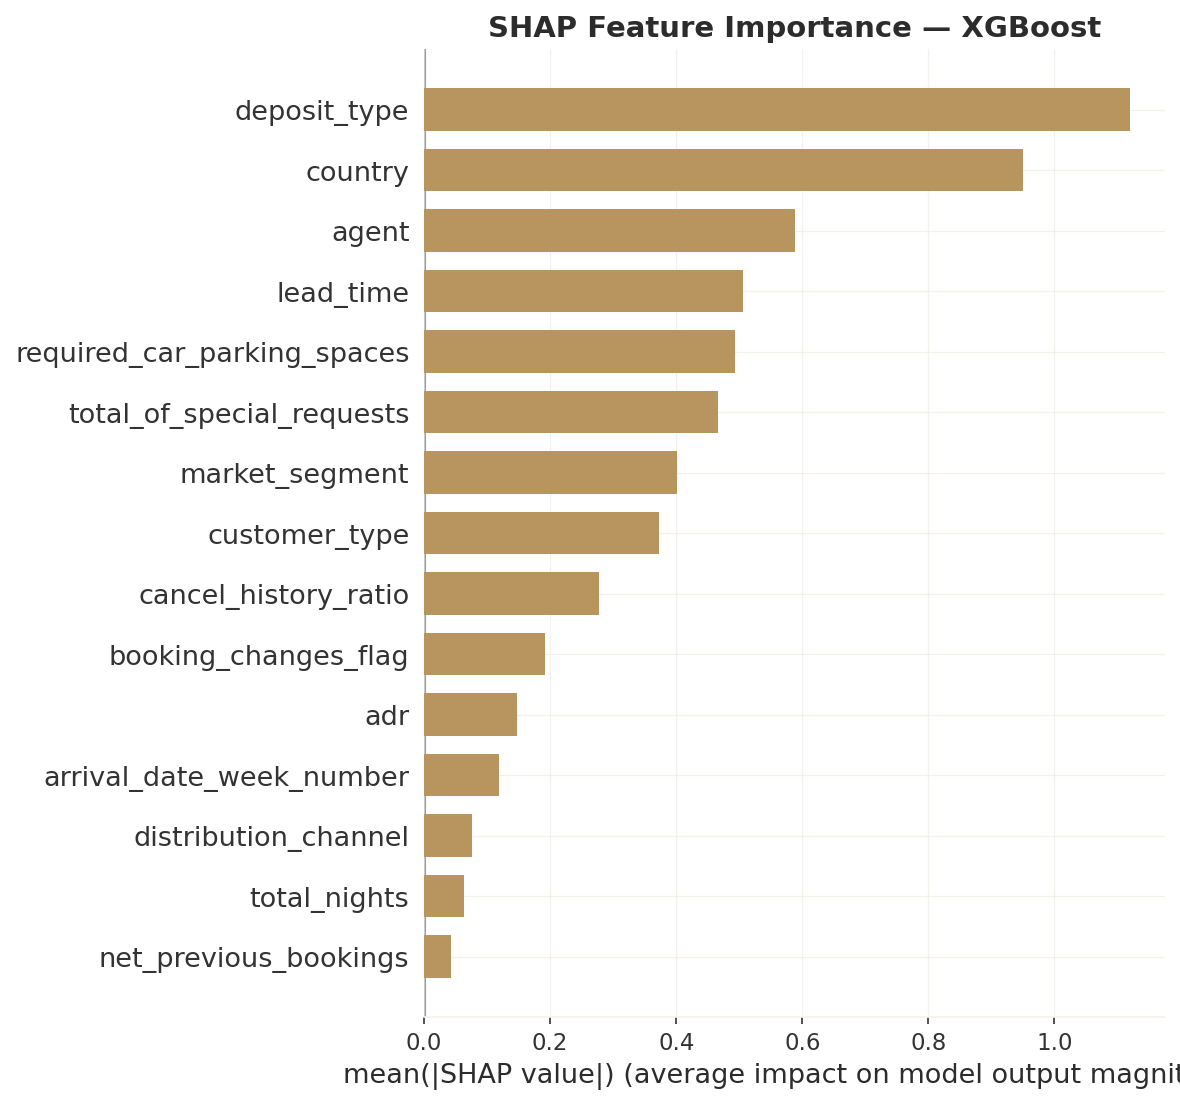

In [9]:
import shap

# SHAP analysis for XGBoost
explainer = shap.TreeExplainer(results['XGBoost']['model'])
shap_sample = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(shap_sample)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False, max_display=15, color=COLORS['primary'])
plt.title('SHAP Feature Importance — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}10b_shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Business Impact & Overbooking Strategy

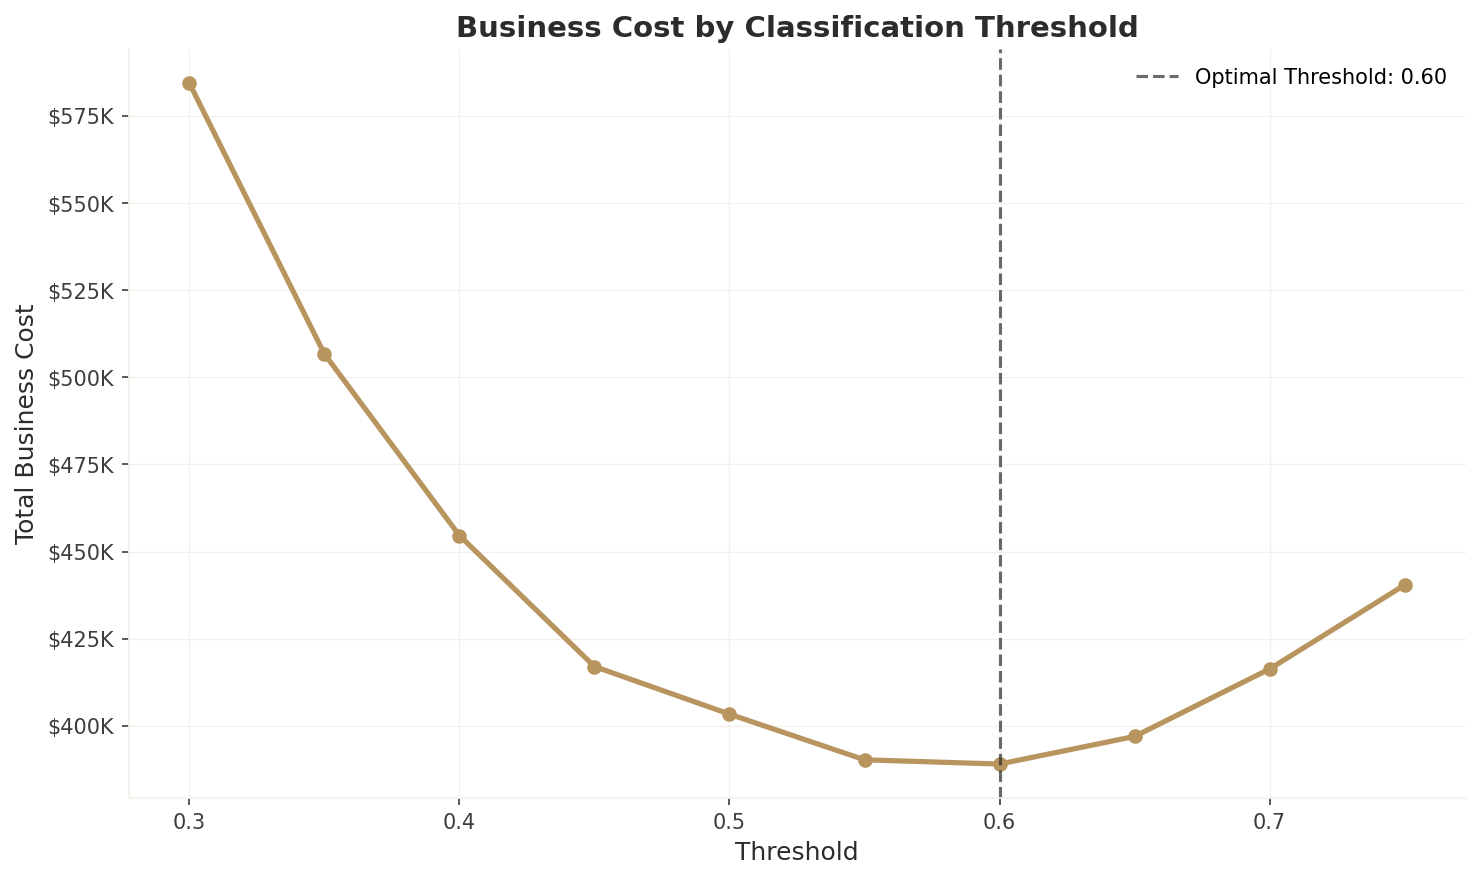


Optimal threshold: 0.60
At this threshold — Precision: 89.47%, Recall: 71.67%


In [10]:
# Business cost analysis: estimate revenue impact at different thresholds
thresholds = np.arange(0.3, 0.8, 0.05)
avg_revenue_per_booking = df[df['is_canceled'] == 0]['total_revenue'].mean()
cost_fp = avg_revenue_per_booking * 0.5   # cost of overbooking (compensation)
cost_fn = avg_revenue_per_booking * 0.3   # cost of empty room (lost revenue opportunity)

threshold_analysis = []
for t in thresholds:
    y_pred_t = (best['y_proba'] >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    total_cost = fp * cost_fp + fn * cost_fn
    threshold_analysis.append({
        'threshold': t, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'total_cost': total_cost,
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
    })

ta = pd.DataFrame(threshold_analysis)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ta['threshold'], ta['total_cost'], color=COLORS['primary'], linewidth=2.5, marker='o')
optimal_idx = ta['total_cost'].idxmin()
ax.axvline(ta.loc[optimal_idx, 'threshold'], color=COLORS['dark'], linestyle='--', alpha=0.7,
           label=f"Optimal Threshold: {ta.loc[optimal_idx, 'threshold']:.2f}")
ax.set_title('Business Cost by Classification Threshold', fontsize=14, fontweight='bold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Total Business Cost')
from src.viz_style import format_axis_currency
format_axis_currency(ax)
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}11_threshold_analysis.png')
plt.show()

print(f"\nOptimal threshold: {ta.loc[optimal_idx, 'threshold']:.2f}")
print(f"At this threshold — Precision: {ta.loc[optimal_idx, 'precision']:.2%}, Recall: {ta.loc[optimal_idx, 'recall']:.2%}")

## 7. Strategic Recommendations

### Model Performance
- **XGBoost** delivers the best performance, with strong ROC-AUC and precision-recall.
- **Lead time**, **deposit type**, and **ADR** are the most important predictors.

### Overbooking Strategy
1. **Risk-tiered overbooking** — Use the model's predicted probability to set overbooking levels:
   - **High risk (>70% cancel prob):** Overbook by 15–20%
   - **Medium risk (40–70%):** Overbook by 5–10%
   - **Low risk (<40%):** No overbooking needed
2. **Dynamic threshold** — Adjust the classification threshold based on occupancy levels and season.
3. **Early intervention** — Flag high-risk bookings for proactive outreach (confirmation calls, incentive offers).

---
*Next: [03_Dynamic_Pricing_Insight.ipynb](03_Dynamic_Pricing_Insight.ipynb) — Pricing optimization analysis.*